# MNIST Handwritten Digit Classification

In this project, I train a neural network to classify handwritten digits
from the MNIST dataset.

The workflow includes:

- Loading a real dataset
- Creating DataLoaders
- Building a neural network
- Training with mini-batches
- Evaluating test accuracy
- Visualizing training loss

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████████████████████████████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 2.22MB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:00<00:00, 8.60MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 3.16MB/s]


In [3]:
print("Training samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Training samples: 60000
Test samples: 10000


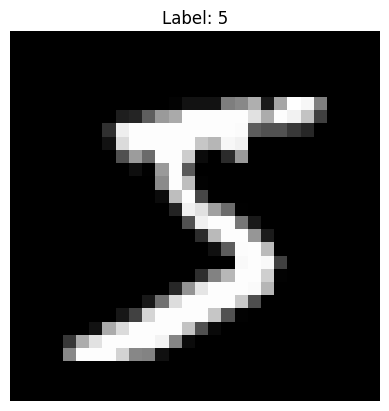

In [4]:
image, label = train_dataset[0]

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")

plt.show()

In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [6]:
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28 * 28, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=128, bias=True)
  (2): ReLU()
  (3): Linear(in_features=128, out_features=10, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1
)

In [8]:
loss_history = []

for epoch in range(5):

    total_loss = 0

    for images, labels in train_loader:

        # 1. Clear old gradients
        optimizer.zero_grad()

        # 2. Forward pass
        outputs = model(images)

        # 3. Calculate loss
        loss = criterion(outputs, labels)

        # 4. Backpropagation
        loss.backward()

        # 5. Update weights
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(train_loader)
    loss_history.append(average_loss)

    print(
        "Epoch:", epoch + 1,
        "Loss:", round(average_loss, 4)
    )

Epoch: 1 Loss: 0.4478
Epoch: 2 Loss: 0.2279
Epoch: 3 Loss: 0.1717
Epoch: 4 Loss: 0.1368
Epoch: 5 Loss: 0.1141


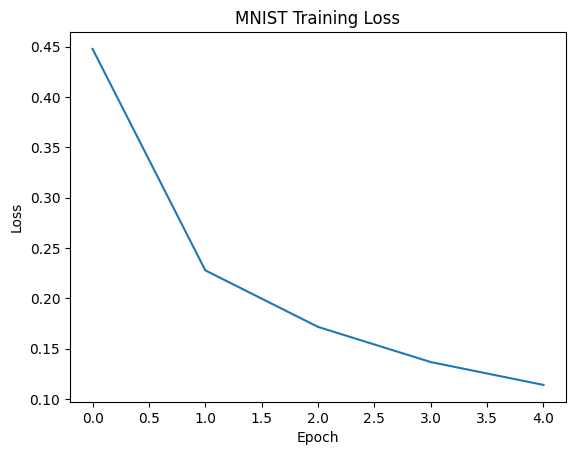

In [9]:
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MNIST Training Loss")

plt.show()

In [10]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)

        correct += (predictions == labels).sum().item()

accuracy = correct / total

print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Accuracy: 96.63 %


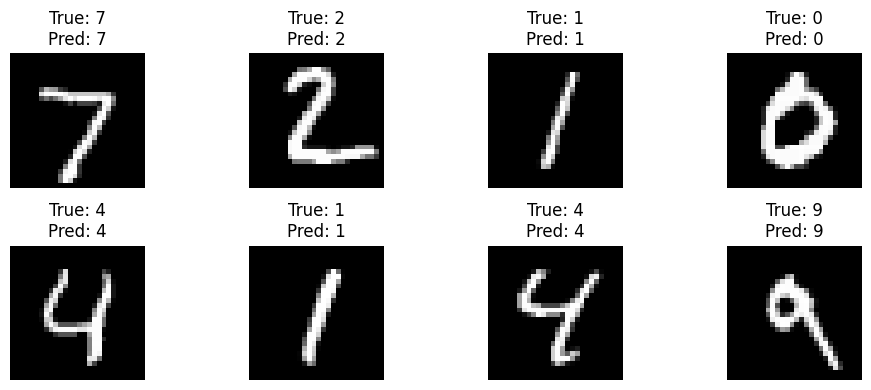

In [11]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images)
    predictions = outputs.argmax(dim=1)

plt.figure(figsize=(10, 4))

for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(
        f"True: {labels[i].item()}\nPred: {predictions[i].item()}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

## Conclusion

In this project, I trained a neural network on the MNIST handwritten digit dataset.

The model used:

- 784 input features
- 128 hidden neurons
- ReLU activation
- 10 output classes
- Cross-entropy loss
- Mini-batch gradient descent

After training, I evaluated the model on the test dataset and measured its classification accuracy.

This project connects the concepts from the previous notebooks with a real deep learning classification task.